# IaC Generation Benchmark Analysis
This notebook analyzes the multi-agent results of running an Infrastructure as Code (IaC) benchmark.
It provides utility to merge results from split runs and visualizations to compare model pass rates, iterations, and token usage.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import glob
import os

# Set plot style
plt.style.use('ggplot')

## 1. Utility: Merge Results
If a model's benchmark was interrupted and resumed, resulting in multiple `.csv` and `.jsonl` files, use this function to merge them into a single file before analysis.

In [2]:
def merge_results(csv_paths, merged_csv_path, jsonl_paths=None, merged_jsonl_path=None):
    """
    Merges multiple CSV and JSONL files from the same model into single files.
    """
    # Merge CSVs
    if csv_paths:
        dfs = [pd.read_csv(f) for f in csv_paths if os.path.exists(f)]
        if dfs:
            merged_df = pd.concat(dfs, ignore_index=True)
            merged_df.to_csv(merged_csv_path, index=False)
            print(f"Merged {len(dfs)} CSVs into {merged_csv_path}")
        else:
            print("No valid CSV files found to merge.")
    
    # Merge JSONLs
    if jsonl_paths and merged_jsonl_path:
        valid_jsonls = [f for f in jsonl_paths if os.path.exists(f)]
        if valid_jsonls:
            with open(merged_jsonl_path, 'w', encoding='utf-8') as outfile:
                for fname in valid_jsonls:
                    with open(fname, 'r', encoding='utf-8') as infile:
                        for line in infile:
                            outfile.write(line)
            print(f"Merged {len(valid_jsonls)} JSONLs into {merged_jsonl_path}")

# Example usage (Uncomment to use):
merge_results(
    csv_paths=['iacgod/CFN Schema Context Deterministic 1/results.csv', 'iacgod/CFN Schema Context Deterministic 2/results.csv'], 
    merged_csv_path='iacgod/modelX_merged.csv',
    jsonl_paths=['iacgod/CFN Schema Context Deterministic 1/results.jsonl', 'iacgod/CFN Schema Context Deterministic 2/results.jsonl'],
    merged_jsonl_path='iacgod/modelX_merged.jsonl'
)

Merged 2 CSVs into iacgod/modelX_merged.csv
Merged 2 JSONLs into iacgod/modelX_merged.jsonl


## 2. Load Data
Define the mapping of models to their respective benchmark results (`.csv` files). The CSV contains high-level metrics like `final_validation_passed`, `iterations_used`, and token/duration statistics.

In [3]:
# Map model names to their CSV file paths
# Assuming 'results.csv' is our baseline model in the current directory
model_files = {
    'Baseline Model': 'modelX_merged.csv',
    # Add other models here:
    # 'Model B': 'modelB_results.csv',
    # 'Model C': 'modelC_results.csv'
}

dataframes = {}
for model, path in model_files.items():
    if os.path.exists(path):
        dataframes[model] = pd.read_csv(path)
    else:
        print(f"Warning: {path} not found.")
        
print(f"Successfully loaded data for models: {list(dataframes.keys())}")

Successfully loaded data for models: []


## 3. Pass Rate Visualization
Compare the overall success rate of different models generating valid IaC templates.

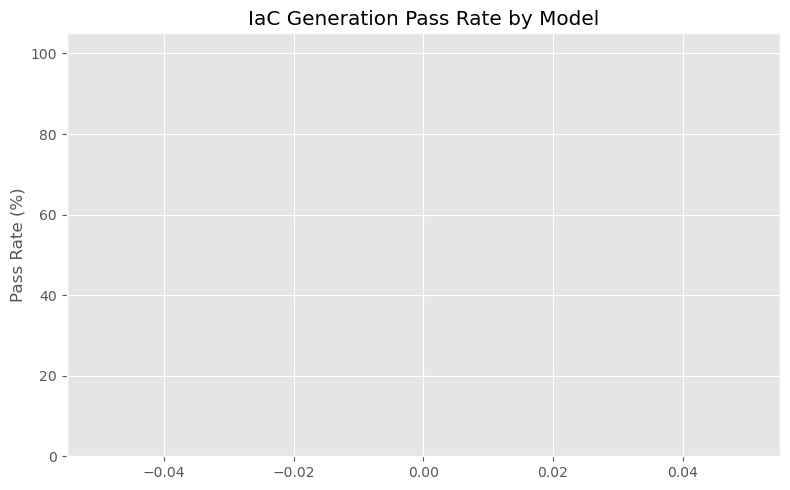

In [4]:
pass_rates = {}
for model, df in dataframes.items():
    # Calculate percentage of runs where final_validation_passed is True
    pass_rate = df['final_validation_passed'].mean() * 100
    pass_rates[model] = pass_rate

plt.figure(figsize=(8, 5))
bars = plt.bar(pass_rates.keys(), pass_rates.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('IaC Generation Pass Rate by Model')
plt.ylabel('Pass Rate (%)')
plt.ylim(0, 105) # Give some headroom for labels

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. In-depth Analysis for LLM Research
Analyzing tokens, iterations, and execution duration helps understand the efficiency and cost-effectiveness of the agents.

### 4.1 Average Iterations Needed to Pass
Lower iterations mean the model gets it right on the first or second try, reducing API costs and latency.

In [ ]:
iterations_data = {}
for model, df in dataframes.items():
    # Filter to only templates that eventually passed
    passed_df = df[df['final_validation_passed'] == True]
    if not passed_df.empty:
        iterations_data[model] = passed_df['iterations_used'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(iterations_data.keys(), iterations_data.values(), color=['#FF9999', '#66B2FF', '#99FF99'])
plt.title('Average Iterations to Pass (Successful Runs Only)')
plt.ylabel('Average Iterations')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 4.2 Cost and Latency: Token Usage vs. Duration
Understanding the correlation between token usage and duration.

In [ ]:
plt.figure(figsize=(10, 6))

for model, df in dataframes.items():
    plt.scatter(df['token_all_tokens'], df['duration_seconds'], alpha=0.6, edgecolors='w', label=model, s=80)

plt.title('Cost & Latency: Token Usage vs Execution Duration')
plt.xlabel('Total Tokens Used (Prompt + Completion)')
plt.ylabel('Duration (Seconds)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.3 Detailed Error Tracking (from JSONL)
By parsing the detailed `results.jsonl`, we can analyze which specific IaC resources/services are causing the most failures.

In [ ]:
# Example analysis of JSONL to extract the most common failing templates
jsonl_file = 'results.jsonl'

if os.path.exists(jsonl_file):
    failed_templates = []
    with open(jsonl_file, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line)
            if not record.get('final_validation_passed', False):
                # Extract filename from ground_truth_path
                template_name = record.get('ground_truth_path', '').split('\\')[-1]
                failed_templates.append(template_name)
                
    if failed_templates:
        failed_series = pd.Series(failed_templates)
        top_failures = failed_series.value_counts().head(10)
        
        plt.figure(figsize=(10, 6))
        top_failures.sort_values().plot(kind='barh', color='coral')
        plt.title('Top 10 Templates Most Commonly Failing')
        plt.xlabel('Number of Failures')
        plt.ylabel('Template Name')
        plt.tight_layout()
        plt.show()
    else:
        print("No failures found in JSONL!")
else:
    print(f"{jsonl_file} not found.")